In [95]:
import pandas as pd
from lightgbm import LGBMRegressor, LGBMClassifier
import numpy as np

import warnings
from fklearn.causal.validation.curves import relative_cumulative_gain_curve, cumulative_effect_curve
from fklearn.causal.validation.auc import area_under_the_relative_cumulative_gain_curve
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from toolz import curry


# Suppress warnings
warnings.filterwarnings("ignore")
np.random.seed(123)

# EXERCISE 1: CROSS SELL EMAIL 

It will be calculated the CATE  using treatments short and long as the same treatment. To calculate the CATE will be use T-LEARNER and X-LEARNER techniques.

In [2]:
dataset=pd.read_csv("cross_sell_email.csv")
dataset["t_binary"]=dataset["cross_sell_email"].apply(lambda x: 0 if 'no_email' in x else 1)
dataset.head()

,gender,cross_sell_email,age,conversion,t_binary
0,0,short,15,0,1
1,1,short,27,0,1
2,1,long,17,0,1
3,1,long,34,0,1
4,1,no_email,14,0,0


In [24]:
dataset.describe()

,gender,age,conversion,t_binary,cate
count,323.000000,323.000000,323.000000,323.000000,323.000000
mean,0.578947,21.102167,0.077399,0.708978,0.057878
std,0.494494,5.777884,0.267639,0.454938,0.112672
min,0.000000,14.000000,0.000000,0.000000,-0.123786
25%,0.000000,17.000000,0.000000,0.000000,-0.013604
50%,1.000000,20.000000,0.000000,1.000000,0.009504
75%,1.000000,24.000000,0.000000,1.000000,0.114984
max,1.000000,44.000000,1.000000,1.000000,0.378799


As the dataset cross_sell_email has been analysed on cap_6, the covariables selected will be the same:

In [18]:
covariables_x_cross_email=['age', 'gender']

# Filter the dataset to get only the rows with 'treatment' equal to 1
dataset_t1 = dataset[dataset['t_binary'] == 1]
dataset_t0 = dataset[dataset['t_binary'] == 0]

## T-LEARNER

This technique is based on using 2 regression models, on for the estimating the counterfactual where all the units have treatment, and another for estimating the counterfactual where all the units don't have treatment. As I have binarize the treatment, now there are more units with treatment. This will make less AUC of the CATE sorted than the X-LEARNER.

LGBMClassifier will be used to predict the counterfactuals as probabilities.

In [57]:
model_counterfactual_t1=LGBMClassifier(objective='binary')
model_counterfactual_t0=LGBMClassifier(objective='binary')

model_counterfactual_t1.fit(dataset_t1[covariables_x_cross_email], dataset_t1['conversion'])

model_counterfactual_t0.fit(dataset_t0[covariables_x_cross_email], dataset_t0['conversion'])


[LightGBM] [Info] Number of positive: 21, number of negative: 208
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000210 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26
[LightGBM] [Info] Number of data points in the train set: 229, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.091703 -> initscore=-2.293016
[LightGBM] [Info] Start training from score -2.293016
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

LGBMClassifier(objective='binary')

Now, the cate can be estimated as a difference between counterfactuals probabilities:

In [32]:
# [:, 1] is used to get only the probabilities to be 1, to conversion
prob_t1 = model_counterfactual_t1.predict_proba(dataset[covariables_x_cross_email])[:, 1]
prob_t0 = model_counterfactual_t0.predict_proba(dataset[covariables_x_cross_email])[:, 1]

dataset = dataset.assign(cate=prob_t1 - prob_t0)

dataset.head()

,gender,cross_sell_email,age,conversion,t_binary,cate
0,0,short,15,0,1,-0.001950
1,1,short,27,0,1,-0.006235
2,1,long,17,0,1,0.320378
3,1,long,34,0,1,-0.006228
4,1,no_email,14,0,0,0.016611


Text(0.5, 1.0, 'T-Learner')

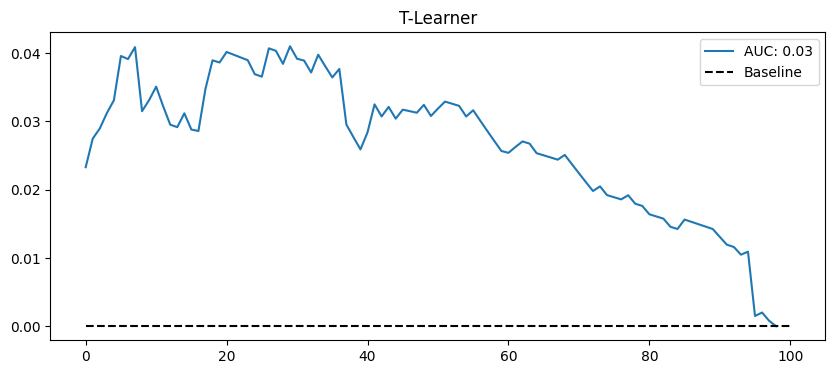

In [126]:
T='t_binary'
y='conversion'

ordered_df = dataset.sort_values(by='cate', ascending=False).reset_index(drop=True)

gain_curve_test = relative_cumulative_gain_curve(ordered_df, T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(ordered_df, T, y, prediction="cate")
"""
gain_curve_test = relative_cumulative_gain_curve(dataset, T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(dataset, T, y, prediction="cate")
"""
plt.figure(figsize=(10,4))
plt.plot(gain_curve_test, color="C0", label=f"AUC: {auc:.2f}")
plt.hlines(0, 0, 100, linestyle="--", color="black", label="Baseline")

plt.legend();
plt.title("T-Learner")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26
[LightGBM] [Info] Number of data points in the train set: 229, number of used features: 2
[LightGBM] [Info] Start training from score 0.091703
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

Text(0.5, 1.0, 'T-Learner')

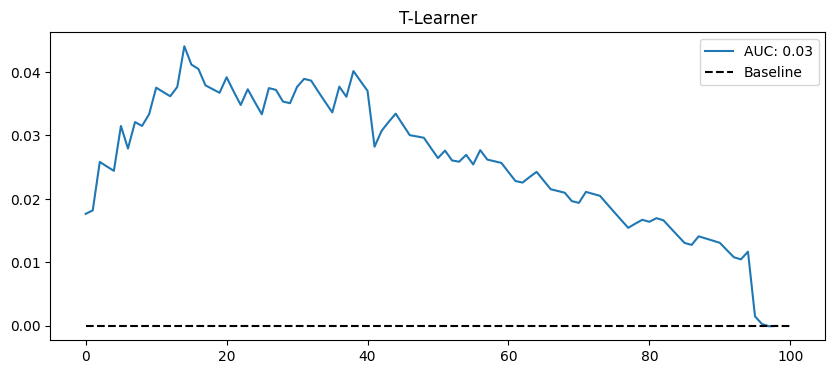

In [53]:
model_counterfactual_reg_t1=LGBMRegressor()
model_counterfactual_reg_t0=LGBMRegressor()

model_counterfactual_reg_t1.fit(dataset_t1[covariables_x_cross_email], dataset_t1['conversion'])

model_counterfactual_reg_t0.fit(dataset_t0[covariables_x_cross_email], dataset_t0['conversion'])


pred_t1_reg = model_counterfactual_reg_t1.predict(dataset[covariables_x_cross_email])
pred_t0_reg = model_counterfactual_reg_t0.predict(dataset[covariables_x_cross_email])

dataset = dataset.assign(cate_reg=pred_t1_reg - pred_t0_reg)

gain_curve_test = relative_cumulative_gain_curve(dataset, T, y, prediction="cate_reg")
auc = area_under_the_relative_cumulative_gain_curve(dataset, T, y, prediction="cate_reg")

plt.figure(figsize=(10,4))
plt.plot(gain_curve_test, color="C0", label=f"AUC: {auc:.2f}")
plt.hlines(0, 0, 100, linestyle="--", color="black", label="Baseline")

plt.legend();
plt.title("T-Learner")

In [44]:
dataset.head()

,gender,cross_sell_email,age,conversion,t_binary,cate,cate_reg
0,0,short,15,0,1,-0.001950,-0.036672
1,1,short,27,0,1,-0.006235,-0.002727
2,1,long,17,0,1,0.320378,0.291252
3,1,long,34,0,1,-0.006228,-0.013604
4,1,no_email,14,0,0,0.016611,0.016888


## X-LEARNER
Calculating the CATE but with X-LEANER technique. This technique is based in 2 stages.

1. Regression of the counterfactuals as the T-LEARNER technique. 

In [73]:
m0 = LGBMRegressor()
m1 = LGBMRegressor()

m0.fit(dataset_t0[covariables_x_cross_email], dataset_t0[y])

m1.fit(dataset_t1[covariables_x_cross_email], dataset_t1[y]);

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000270 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20
[LightGBM] [Info] Number of data points in the train set: 94, number of used features: 2
[LightGBM] [Info] Start training from score 0.042553
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

2. Imputing the missing potential outcomes.

In [74]:
tau_hat_0 = m1.predict(dataset_t0[covariables_x_cross_email]) - dataset_t0[y]
tau_hat_1 = dataset_t1[y] - m0.predict(dataset_t1[covariables_x_cross_email])

m_tau_0 = LGBMRegressor()
m_tau_1 = LGBMRegressor()


m_tau_0.fit(dataset_t0[covariables_x_cross_email], tau_hat_0)
m_tau_1.fit(dataset_t1[covariables_x_cross_email], tau_hat_1);

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000230 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20
[LightGBM] [Info] Number of data points in the train set: 94, number of used features: 2
[LightGBM] [Info] Start training from score 0.063504
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

Getting the CATE weighting prediction from stage 2 with PS(propensity score).

In [79]:
ps_model = LogisticRegression()
ps_model.fit(dataset[covariables_x_cross_email], dataset[T])

ps_test = ps_model.predict_proba(dataset[covariables_x_cross_email])[:, 1]

x_cate_test = dataset.assign(
    cate_x_learner=(ps_test*m_tau_0.predict(dataset[covariables_x_cross_email]) +
          (1-ps_test)*m_tau_1.predict(dataset[covariables_x_cross_email])
         )
)

x_cate_test.head()

,gender,cross_sell_email,age,conversion,t_binary,cate,cate_reg,cate_x_learner
0,0,short,15,0,1,-0.001950,-0.036672,0.030867
1,1,short,27,0,1,-0.006235,-0.002727,0.006370
2,1,long,17,0,1,0.320378,0.291252,0.279815
3,1,long,34,0,1,-0.006228,-0.013604,0.005888
4,1,no_email,14,0,0,0.016611,0.016888,0.064097


Text(0.5, 1.0, 'X-Learner')

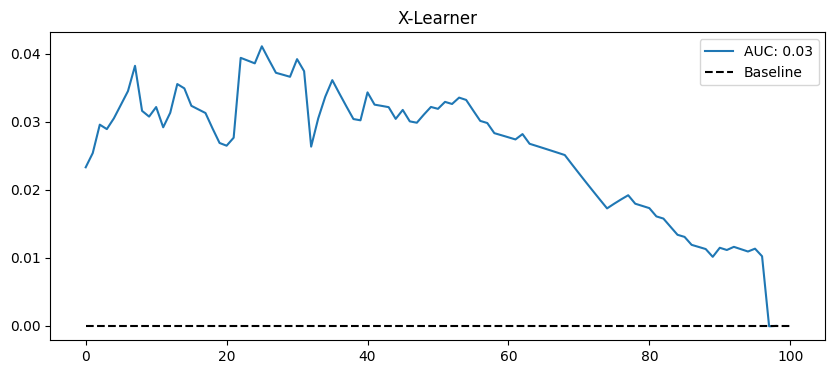

In [80]:
gain_curve_test = relative_cumulative_gain_curve(x_cate_test, T, y, prediction="cate_x_learner")
auc = area_under_the_relative_cumulative_gain_curve(x_cate_test, T, y, prediction="cate_x_learner")

plt.figure(figsize=(10,4))
plt.plot(gain_curve_test, color="C0", label=f"AUC: {auc:.2f}")
plt.hlines(0, 0, 100, linestyle="--", color="black", label="Baseline")

plt.legend();
plt.title("X-Learner")

# EXERCISE 2: CREDIT LIMIT

As te treatment is continous, to estimate the CATE will be used S-LEARNER and R-LEARNER techniques.

In [114]:
dataset_credit=pd.read_csv("risk_data.csv")
dataset_credit.describe()

,wage,educ,exper,married,credit_score1,credit_score2,credit_limit,default
count,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1061.518000,13.48886,11.55078,0.896120,471.102540,487.861920,2848.570000,0.150800
std,412.304605,2.20769,4.36497,0.305108,113.401589,117.063919,1372.623633,0.357857
min,120.000000,9.00000,1.00000,0.000000,34.000000,36.000000,200.000000,0.000000
25%,770.000000,12.00000,8.00000,1.000000,397.000000,411.000000,1900.000000,0.000000
50%,1010.000000,12.00000,11.00000,1.000000,466.000000,482.000000,2700.000000,0.000000
75%,1270.000000,16.00000,15.00000,1.000000,534.000000,571.000000,3700.000000,0.000000
max,3310.000000,18.00000,23.00000,1.000000,1034.000000,1036.000000,8500.000000,1.000000


## S-LEARNER

This technique uses Target Transformation to get the CATE.

In [103]:
T = "credit_limit"
y = "default"
cov_x=['wage','credit_score1','credit_score2']
s_learner = LGBMRegressor()
s_learner.fit(dataset_credit[cov_x+[T]], dataset_credit[y]);

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000308 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 446
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 4
[LightGBM] [Info] Start training from score 0.150800


It is needed to define a grid of treatments to substitute the continous treatment.

In [122]:
n_groups=4
step=dataset_credit[T].max()/n_groups
last_step=0
steps=[]
for _ in range(n_groups):
    steps.append(step+last_step)
    last_step=steps[-1]

print(f"Groups:{steps}")

t_grid = pd.DataFrame(dict(key=1,
                           credit_limit_group=np.array(steps)))

# it is created a version of each unit within each group of the grid
dataset_credit_with_pred = (dataset_credit
           .assign(key=1)
           .merge(t_grid)
           # make predictions after expansion
           .assign(default_hat = lambda d: s_learner.predict(d[cov_x+[T]])))

dataset_credit_with_pred.head(8)

Groups:[2125.0, 4250.0, 6375.0, 8500.0]


,wage,educ,exper,married,credit_score1,credit_score2,credit_limit,default,key,credit_limit_group,default_hat
0,950.0,11,16,1,500.0,518.0,3200.0,0,1,2125.0,0.142640
1,950.0,11,16,1,500.0,518.0,3200.0,0,1,4250.0,0.142640
2,950.0,11,16,1,500.0,518.0,3200.0,0,1,6375.0,0.142640
3,950.0,11,16,1,500.0,518.0,3200.0,0,1,8500.0,0.142640
4,780.0,11,7,1,414.0,429.0,1700.0,0,1,2125.0,0.185927
5,780.0,11,7,1,414.0,429.0,1700.0,0,1,4250.0,0.185927
6,780.0,11,7,1,414.0,429.0,1700.0,0,1,6375.0,0.185927
7,780.0,11,7,1,414.0,429.0,1700.0,0,1,8500.0,0.185927


Now, the CATE is estimated:

In [125]:
@curry
def linear_effect(df, y, t):
    return np.cov(df[y], df[t])[0, 1]/df[t].var()


cate = (dataset_credit_with_pred
        .groupby("credit_limit_group")
        .apply(linear_effect(t="credit_limit", y="default_hat"))
        .rename("cate"))

test_s_learner_pred = dataset_credit.join(cate)

test_s_learner_pred.head()

KeyboardInterrupt: 

In [ ]:
from fklearn.causal.validation.auc import area_under_the_relative_cumulative_gain_curve
from fklearn.causal.validation.curves import relative_cumulative_gain_curve

gain_curve_test = relative_cumulative_gain_curve(test_s_learner_pred, T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(test_s_learner_pred, T, y, prediction="cate")

plt.figure(figsize=(10, 4))
plt.plot(gain_curve_test, color="C0", label=f"AUC: {auc:.2f}")
plt.hlines(0, 0, 100, linestyle="--", color="black", label="Baseline")

plt.legend();
plt.title("S-Learner")